Первая краевая задача для уравнения теплопроводности. 
### ИР 2. Нестационарные задачи.

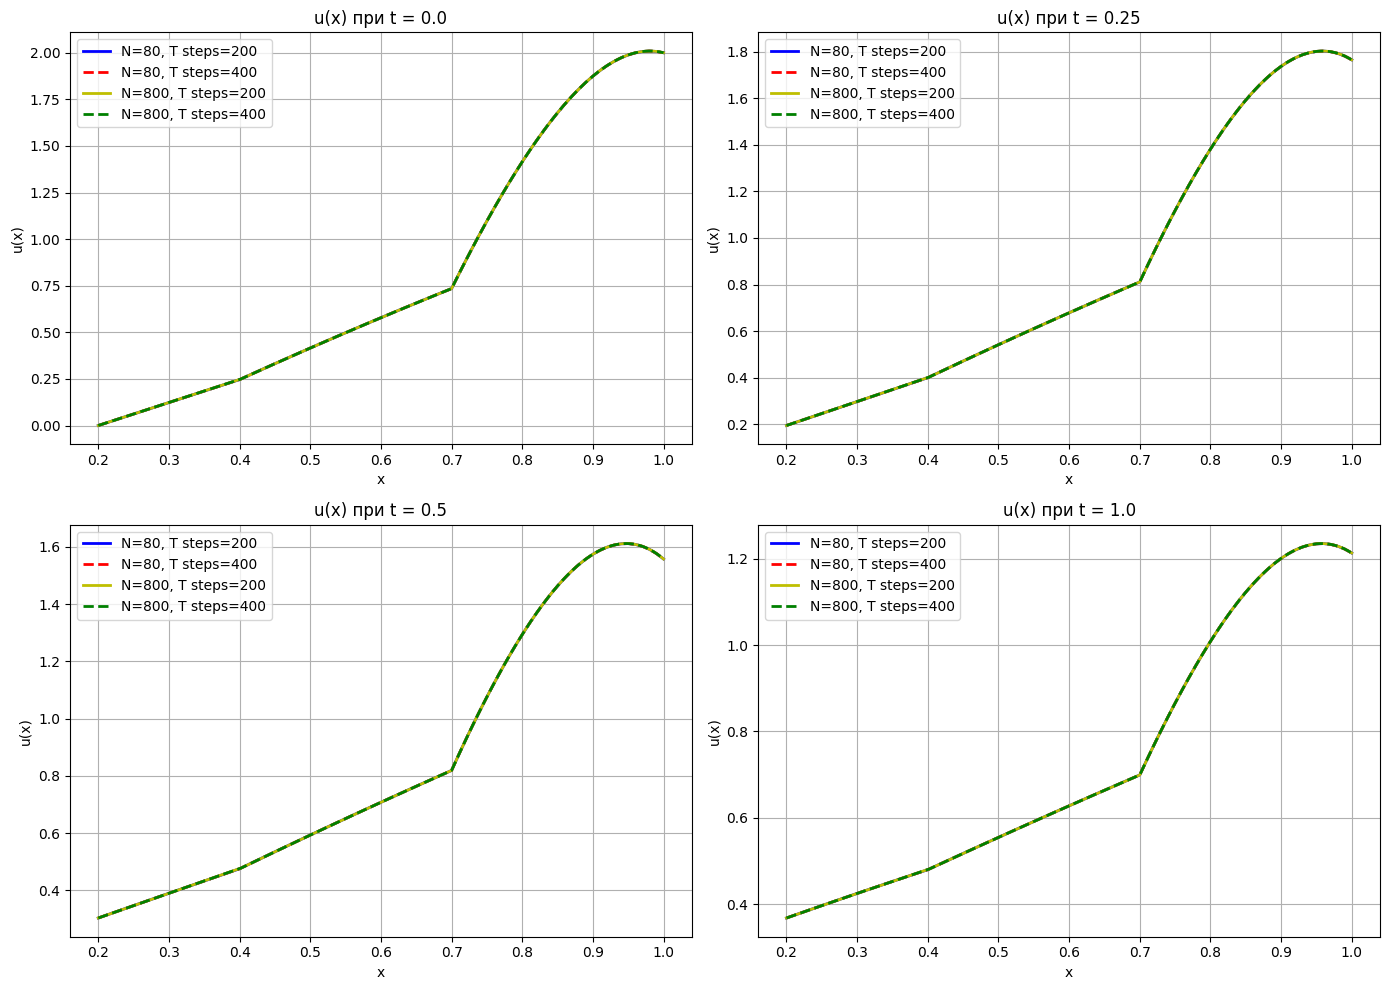

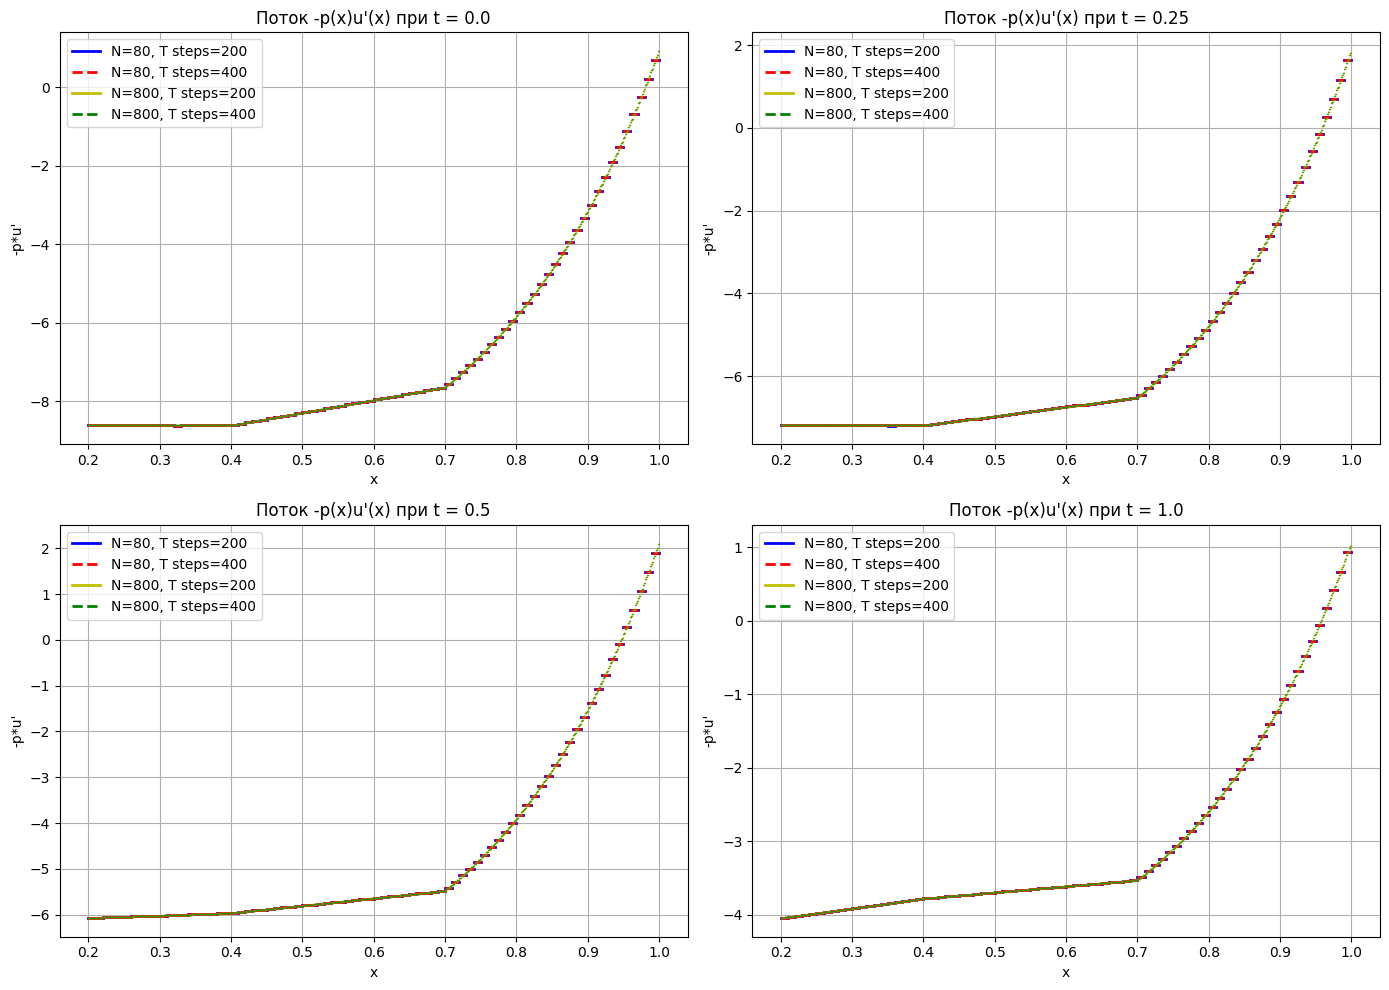

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Параметры задачи ---
# Границы отрезка
a, b = 0.2, 1.0

# Точки разрыва коэффициентов (Вариант 2 из табл. 1)
a1, a2, a3, a4 = 0.2, 0.4, 0.7, 1.0

# Правая часть f(x, t) (Вариант 2 из табл. 1)
def f1(x, t): return np.sqrt(2 + x) * np.sin(t)
def f2(x, t): return 4 * np.log(2 + x) * np.exp(-t)
def f3(x, t): return np.exp(4 * x) * np.cos(t)

def f(x, t):
    if x < a2 - 1e-9: return f1(x, t)
    elif x < a3 - 1e-9: return f2(x, t)
    else: return f3(x, t)

# Коэффициенты p, q, c (Вариант 3 из табл. 2)
c1, c2, c3 = 0.8, 0.2, 0.4
p1, p2, p3 = 7.0, 5.0, 1.0
q1, q2, q3 = 0.0, 1.0, 2.0

def p(x):
    if x < a2 - 1e-9: return p1
    elif x < a3 - 1e-9: return p2
    else: return p3

def q(x):
    if x < a2 - 1e-9: return q1
    elif x < a3 - 1e-9: return q2
    else: return q3

def c_func(x):
    if x < a2 - 1e-9: return c1
    elif x < a3 - 1e-9: return c2
    else: return c3

# Граничные условия (Вариант 4 из табл. 3)
def u_a(t): return t * np.exp(-t)
def u_b(t): return 2 * np.exp(-t / 2)


# --- Вспомогательные функции ---
def solve_tridiagonal(A_mat, F_vec):
    """Метод прогонки для трехдиагональной матрицы"""
    n = len(F_vec)
    alpha = np.zeros(n)
    beta = np.zeros(n)
    
    alpha[0] = -A_mat[0, 1] / A_mat[0, 0] if n > 1 else 0
    beta[0] = F_vec[0] / A_mat[0, 0]
    
    for i in range(1, n - 1):
        denom = A_mat[i, i-1] * alpha[i-1] + A_mat[i, i]
        alpha[i] = -A_mat[i, i+1] / denom
        beta[i] = (F_vec[i] - A_mat[i, i-1] * beta[i-1]) / denom
        
    u = np.zeros(n)
    denom_last = A_mat[n-1, n-2] * alpha[n-2] + A_mat[n-1, n-1]
    u[n-1] = (F_vec[n-1] - A_mat[n-1, n-2] * beta[n-2]) / denom_last
    
    for i in range(n-2, -1, -1):
        u[i] = alpha[i] * u[i+1] + beta[i]
        
    return u


# --- Основная функция МКЭ ---
def gal(N, T_steps, T_end=1.0):
    tau = T_end / T_steps
    h = (b - a) / N
    x = np.linspace(a, b, N + 1)
    
    K = np.zeros((N + 1, N + 1))
    M = np.zeros((N + 1, N + 1))
    C = np.zeros((N + 1, N + 1))
    
    # 1. Сборка глобальных матриц K, M, C
    for e in range(N):
        x_L = x[e]
        x_R = x[e+1]
        x_mid = (x_L + x_R) / 2
        
        # Значения коэффициентов берем по центру элемента
        p_e = p(x_mid)
        q_e = q(x_mid)
        c_e = c_func(x_mid)
        
        K_loc = np.array([[1, -1], [-1, 1]]) * (p_e / h)
        M_loc = np.array([[2, 1], [1, 2]]) * (q_e * h / 6)
        C_loc = np.array([[2, 1], [1, 2]]) * (c_e * h / 6)
        
        for local_i in range(2):
            for local_j in range(2):
                K[e + local_i, e + local_j] += K_loc[local_i, local_j]
                M[e + local_i, e + local_j] += M_loc[local_i, local_j]
                C[e + local_i, e + local_j] += C_loc[local_i, local_j]
                
    A_CN = C + (tau / 2) * (K + M) # Левая часть Кранка-Николсона
    B_CN = C - (tau / 2) * (K + M) # Правая часть Кранка-Николсона
    
    # 2. Решение первой лабораторной работы (нахождение u0 при t=0)
    F_0 = np.zeros(N + 1)
    for e in range(N):
        x_L = x[e]
        x_R = x[e+1]
        
        nodes = np.array([-np.sqrt(1/3), np.sqrt(1/3)])
        mapped_nodes = 0.5 * h * nodes + 0.5 * (x_L + x_R)
        weights = 0.5 * h * np.array([1, 1])
        
        I0 = np.sum(weights * np.array([f(n, 0) * (x_R - n) / h for n in mapped_nodes]))
        I1 = np.sum(weights * np.array([f(n, 0) * (n - x_L) / h for n in mapped_nodes]))
        
        F_0[e] += I0
        F_0[e+1] += I1
        
    A_0 = K + M
    G_0 = F_0.copy()
    A_0[0, :] = 0; A_0[0, 0] = 1; G_0[0] = u_a(0)
    A_0[N, :] = 0; A_0[N, N] = 1; G_0[N] = u_b(0)
    
    u_0 = solve_tridiagonal(A_0, G_0)
    
    def calc_flux(u_curr):
        flux = np.zeros(N)
        for e in range(N):
            x_mid = (x[e] + x[e+1]) / 2
            flux[e] = -p(x_mid) * (u_curr[e+1] - u_curr[e]) / h
        return flux
        
    u_out = {0.0: u_0.copy()}
    flux_out = {0.0: calc_flux(u_0)}
    
    u_prev = u_0.copy()
    F_prev = F_0.copy()
    
    # 4 требуемых момента времени: 0, 0.25, 0.5, 1.0 (при T_end = 1.0)
    targets = [int(0.25 * T_steps), int(0.5 * T_steps), T_steps]
    target_times = [0.0]
    
    # 3. Цикл по времени
    for step in range(1, T_steps + 1):
        t = step * tau
        
        F_curr = np.zeros(N + 1)
        for e in range(N):
            x_L = x[e]
            x_R = x[e+1]
            
            nodes = np.array([-np.sqrt(1/3), np.sqrt(1/3)])
            mapped_nodes = 0.5 * h * nodes + 0.5 * (x_L + x_R)
            weights = 0.5 * h * np.array([1, 1])
            
            I0 = np.sum(weights * np.array([f(n, t) * (x_R - n) / h for n in mapped_nodes]))
            I1 = np.sum(weights * np.array([f(n, t) * (n - x_L) / h for n in mapped_nodes]))
            
            F_curr[e] += I0
            F_curr[e+1] += I1
            
        G = B_CN @ u_prev + (tau / 2) * (F_curr + F_prev)
        
        # Граничные условия Дирихле на краях
        A_mod = A_CN.copy()
        G_mod = G.copy()
        A_mod[0, :] = 0; A_mod[0, 0] = 1; G_mod[0] = u_a(t)
        A_mod[N, :] = 0; A_mod[N, N] = 1; G_mod[N] = u_b(t)
        
        u_curr = solve_tridiagonal(A_mod, G_mod)
        
        if step in targets:
            u_out[t] = u_curr.copy()
            flux_out[t] = calc_flux(u_curr)
            target_times.append(t)
            
        u_prev = u_curr.copy()
        F_prev = F_curr.copy()
        
    return x, u_out, flux_out, target_times


# --- Исполнение и вывод графиков ---
# Задаем шаги h и tau для двух прогонов
N1, T1 = 80, 200
N2, T2 = 80, 400
N3, T3 = 800, 200
N4, T4 = 800, 400

x1, u1_dict, f1_dict, t_list = gal(N1, T1)
x2, u2_dict, f2_dict, _ = gal(N2, T2)
x3, u3_dict, f3_dict, t_list = gal(N3, T4)
x4, u4_dict, f4_dict, _ = gal(N4, T4)

# 1. Построение графиков функции u(x)
plt.figure(figsize=(14, 10))
for idx, t in enumerate(t_list):
    plt.subplot(2, 2, idx + 1)
    plt.plot(x1, u1_dict[t], 'b-', lw=2, label=f"N={N1}, T steps={T1}")
    plt.plot(x2, u2_dict[t], 'r--', lw=2, label=f"N={N2}, T steps={T2}")
    plt.plot(x3, u3_dict[t], 'y-', lw=2, label=f"N={N3}, T steps={T3}")
    plt.plot(x4, u4_dict[t], 'g--', lw=2, label=f"N={N4}, T steps={T4}")
    plt.title(f"u(x) при t = {t}")
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.grid()
    plt.legend()
plt.tight_layout()
plt.show()

# 2. Построение графиков потока -p(x)u'(x)
plt.figure(figsize=(14, 10))
for idx, t in enumerate(t_list):
    plt.subplot(2, 2, idx + 1)
    
    # Поток кусочно-постоянен на каждом конечном элементе
    for e in range(N1):
        plt.plot([x1[e], x1[e+1]], [f1_dict[t][e], f1_dict[t][e]], 'b-', lw=2)
    plt.plot([], [], 'b-', lw=2, label=f"N={N1}, T steps={T1}")
        
    for e in range(N2):
        plt.plot([x2[e], x2[e+1]], [f2_dict[t][e], f2_dict[t][e]], 'r--', lw=2)
    plt.plot([], [], 'r--', lw=2, label=f"N={N2}, T steps={T2}")

    for e in range(N3):
        plt.plot([x3[e], x3[e+1]], [f3_dict[t][e], f3_dict[t][e]], 'y-', lw=1)
    plt.plot([], [], 'y-', lw=2, label=f"N={N3}, T steps={T3}")
        
    for e in range(N4):
        plt.plot([x4[e], x4[e+1]], [f4_dict[t][e], f4_dict[t][e]], 'g--', lw=1)
    plt.plot([], [], 'g--', lw=2, label=f"N={N4}, T steps={T4}") 
        
    plt.title(f"Поток -p(x)u'(x) при t = {t}")
    plt.xlabel("x")
    plt.ylabel("-p*u'")
    plt.grid()
    plt.legend()
plt.tight_layout()
plt.show()

# 